## EDA

## Steps For EDA

#### Categorise the given column as a Numerical , Categorical , Mixed Data type column

#### Univariate Analysis --- > Numerical Column or Categorical Column

#### Numerical Column Analysis --- > Distribution of the Data --- > Histogram , kdeplot
#### ---- > Outliers --- > BoxplotI
#### ---- > Handle Missing Values

#### Categorical Column Analysis --- > Distribution of the Data --- > countplot
#### ---- > Missing Values --- >

#### Bivariate Analysis ---> Numerical Numerical column ---> scatterplot
#### Numerical Categorical column ---> barplot
#### Categorical Categorical ----> Heatmap

#### EDA ---> Feature Engineering ---> creation of new features from existing data or feature

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Titanic-Dataset.csv') ## titanic dataset for EDA

In [25]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum() ## missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
## Univariate Analysis on Numerical Column --- >
## Data Distribution of the Numerical Column --- >describe() & Plotting --- > kdeplot or histogram
## Outlier detection ----> boxplot

In [10]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [15]:
df[df['Age'] == 80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


In [17]:
## outlier present in this column or nor 'Age'

<Axes: xlabel='Age'>

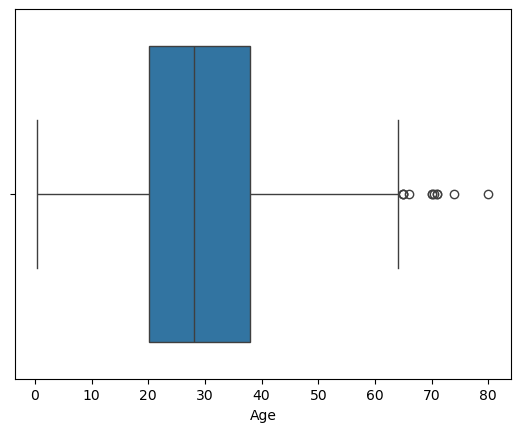

In [19]:
sns.boxplot(data=df,x='Age')

In [20]:
## no outliers still if we want to go with imputation we can go with median

In [ ]:
df['Age'].isnull().sum() ## we cant go with dropna()

np.int64(177)

In [22]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [23]:
df['Age'].isnull().sum()

np.int64(0)

In [27]:
df['Age'].describe() ## 177 missing values of age are filled with median value

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

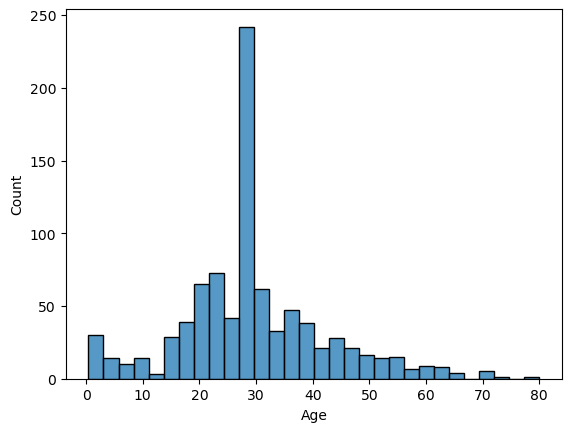

In [28]:
sns.histplot(data=df,x='Age')

<Axes: xlabel='Age', ylabel='Density'>

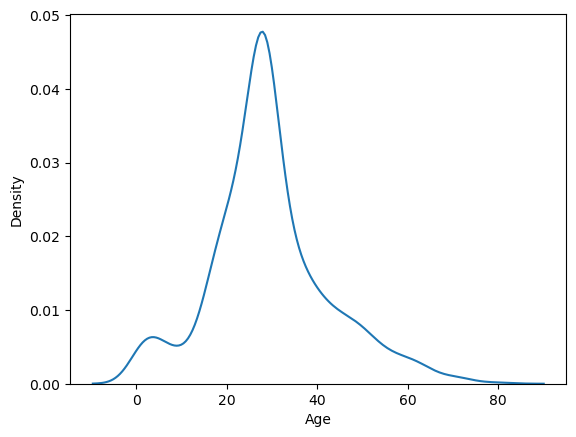

In [29]:
sns.kdeplot(data=df,x='Age')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [30]:
## Next Numerical column analysis

In [33]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [36]:
df['Fare'].isnull().sum()

np.int64(0)

In [37]:
## outlier max = 512 dollars right outlier exists
df[df['Fare'] == 512.329200]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [44]:
df[df['Ticket'] == 'PC 17755']['Name'] ## 3 members

258                      Ward, Miss. Anna
679    Cardeza, Mr. Thomas Drake Martinez
737                Lesurer, Mr. Gustave J
Name: Name, dtype: object

<Axes: xlabel='Fare'>

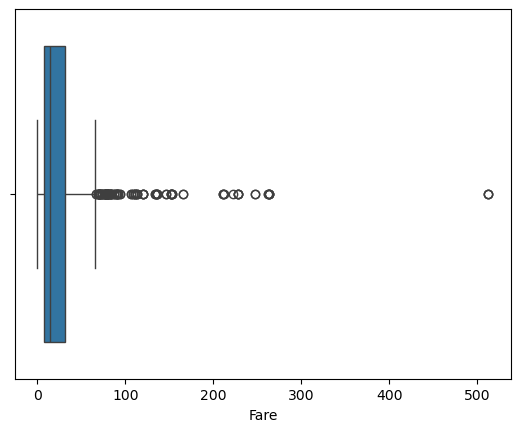

In [45]:
sns.boxplot(data = df, x='Fare')

<Axes: xlabel='Fare', ylabel='Count'>

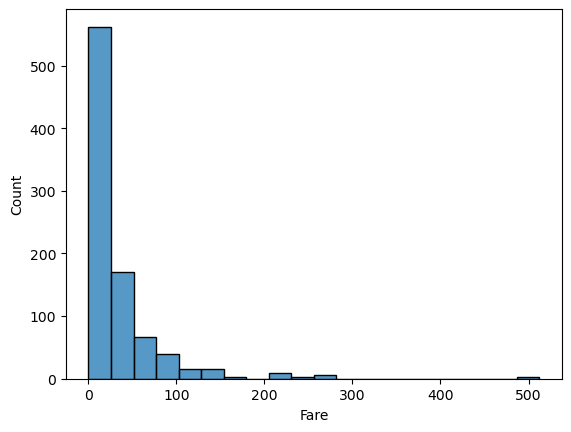

In [52]:
sns.histplot(data = df, x='Fare', bins = 20)

In [54]:
## Univariate Analysis ----> Categorical Column
## Data Distribution ---> value_counts ---> countplot()
## Handling Missing Values ---> Mode or Most Frequent Imputation

In [55]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

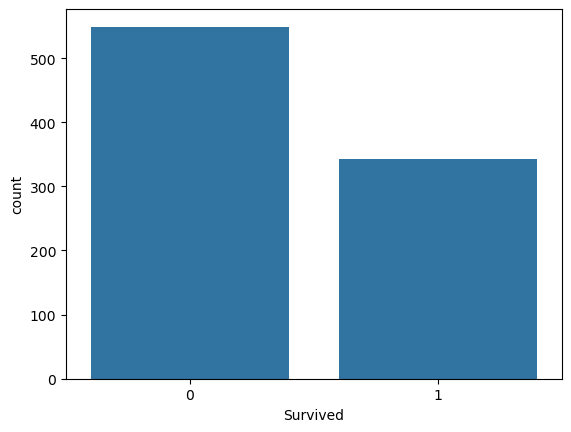

In [57]:
sns.countplot(data = df, x='Survived')

In [58]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked', ylabel='Count'>

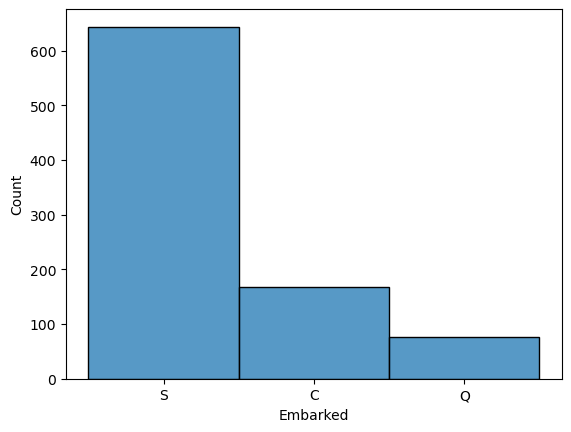

In [59]:
sns.histplot(data = df, x='Embarked')

In [60]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Bivariate Analysis

## Numerical Numerical
## Numerical Categorical
## Categorical Categorical

<Axes: xlabel='Age', ylabel='Fare'>

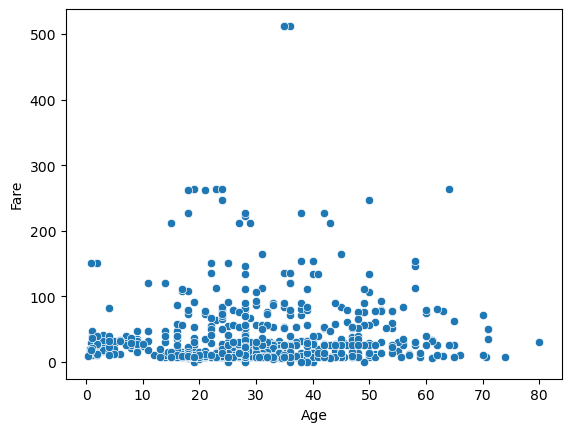

In [65]:
# Bivariate Analysis
## scatterplot the relation b/w numerical and numerical
sns.scatterplot(data=df,x='Age',y='Fare')

<Axes: xlabel='Pclass', ylabel='Fare'>

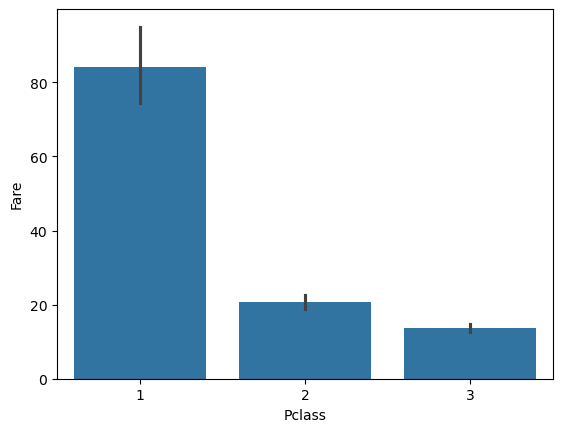

In [68]:
sns.barplot(data=df,x='Pclass',y='Fare') ## num -- num

<Axes: xlabel='Embarked', ylabel='Fare'>

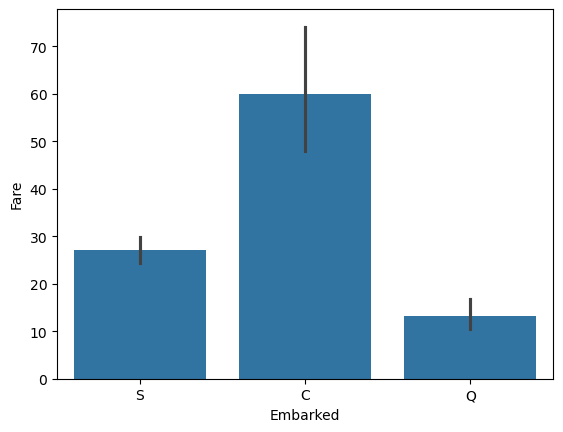

In [70]:
sns.barplot(data=df,x='Embarked',y='Fare')## categorical ---num

In [71]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp', ylabel='Fare'>

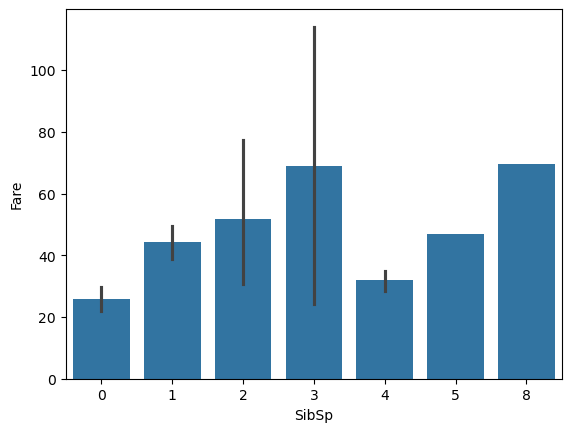

In [73]:
sns.barplot(data=df,x='SibSp',y='Fare') # no discount on sibsp count

<Axes: xlabel='Sex', ylabel='Fare'>

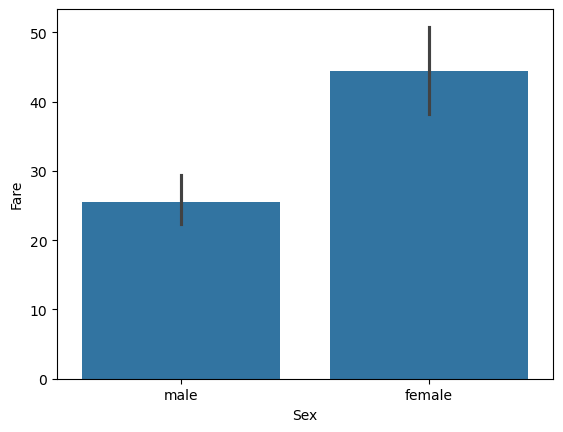

In [75]:
sns.barplot(data=df,x='Sex',y='Fare') ## cat -- num

In [77]:
### Categorical -- Categorical analysis ---->crosstab()
### crosstab() ---> two categories as input on which we can peform the analysis

pd.crosstab(df['Pclass'],df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

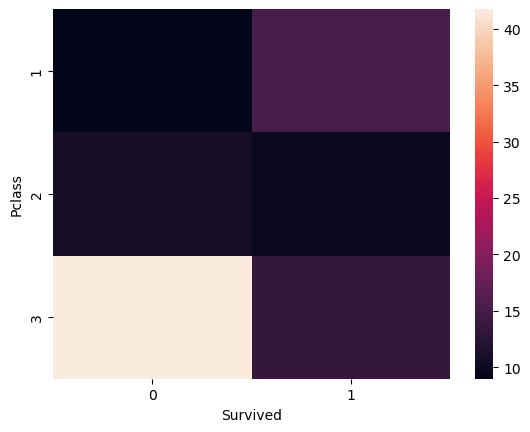

In [82]:
sns.heatmap(pd.crosstab(df['Pclass'],df['Survived'],normalize = True)* 100)

In [83]:
pd.crosstab(df['Sex'],df['Survived'],normalize = True)* 100

Survived,0,1
Sex,,
female,9.090909,26.150393
male,52.525253,12.233446


In [85]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='Sex'>

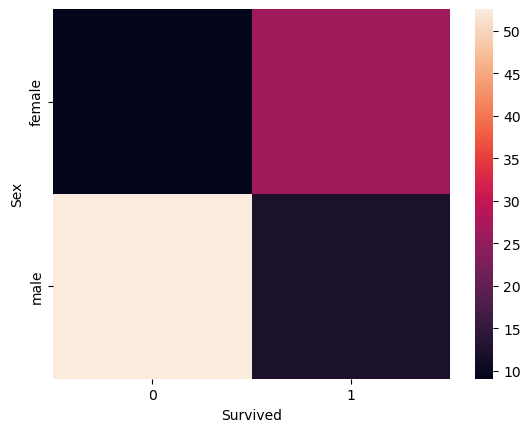

In [84]:
sns.heatmap(pd.crosstab(df['Sex'],df['Survived'],normalize = True)* 100)

In [87]:
pd.crosstab(df['Embarked'],df['Survived'],normalize = True)* 100

Survived,0,1
Embarked,,
C,8.436445,10.461192
Q,5.286839,3.374578
S,48.031496,24.409449
